<a href="https://colab.research.google.com/github/stephenebert/Springboard/blob/main/_MiniProject_Trees_and_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part a

**1. Use load_breast_cancer to load the Breast Cancer Wisconsin dataset as a Pandas dataframe.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
#load in the data and see what it looks like
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
dir(data)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
pd.DataFrame(data.data)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
#Name the columns
df = pd.DataFrame(data.data, columns = data.feature_names)

In [7]:
df['target'] = data.target

In [8]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


**2. Split the dataset into training and test sets.**

In [9]:
X = df.drop('target', axis = 1)
y = df.target

In [10]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [11]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

**3. Display the first five rows of data and make sure everything looks ok. You should have already explored the data a bit in the logistic regression mini-project so there's no need to conduct further EDA.**

In [13]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Part b

**1. Use Scikit-Learn's DecisionTreeClassifier to fit a model on the training data.**

In [14]:
model = DecisionTreeClassifier(random_state = 0)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

**2. Visualize the resulting tree using plot_tree.**

In [15]:
X_train.columns #column names

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

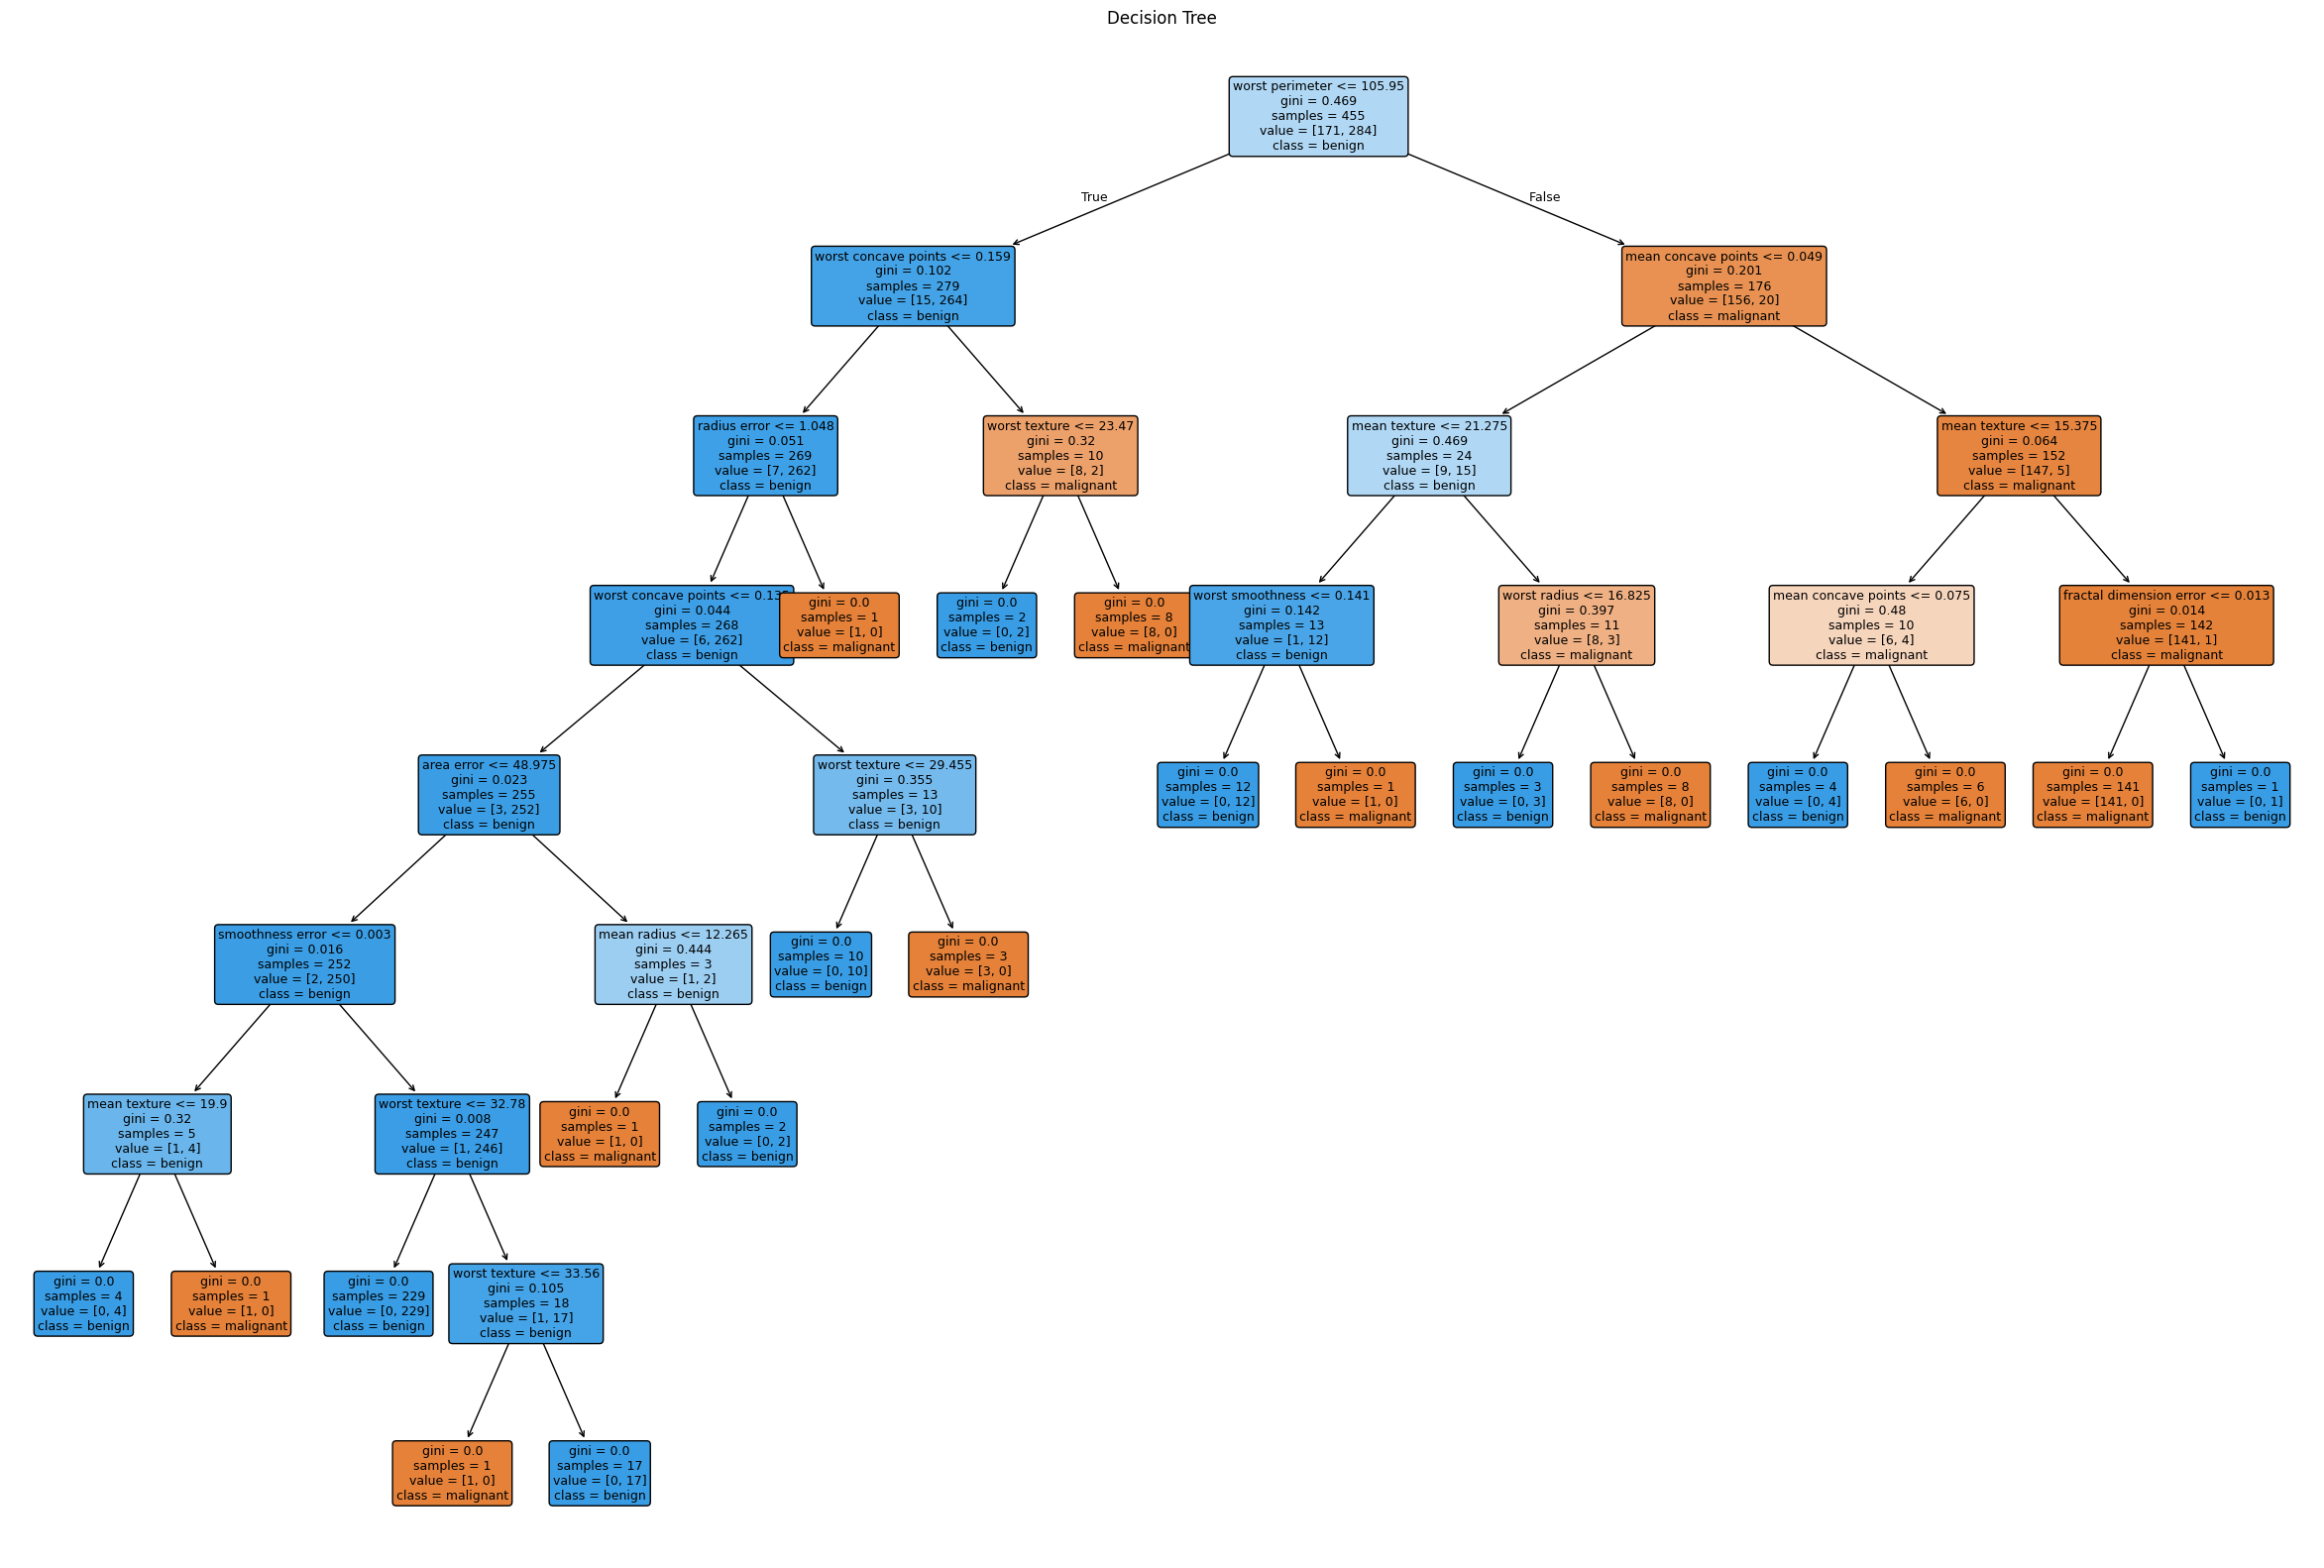

In [16]:
plt.figure(figsize=(30,20))
plot_tree(model, feature_names = X_train.columns, class_names = data.target_names, filled = True, rounded = True, fontsize=9)
plt.title('Decision Tree')
plt.show()

**3. Iterate on the first two steps by trying different inputs to the decision tree classifier. What happens if you change the max depth? How about the maximum number of lead nodes? From the visualization, make sure you're able to understand how to descend the decision tree to arrive at a prediction.**

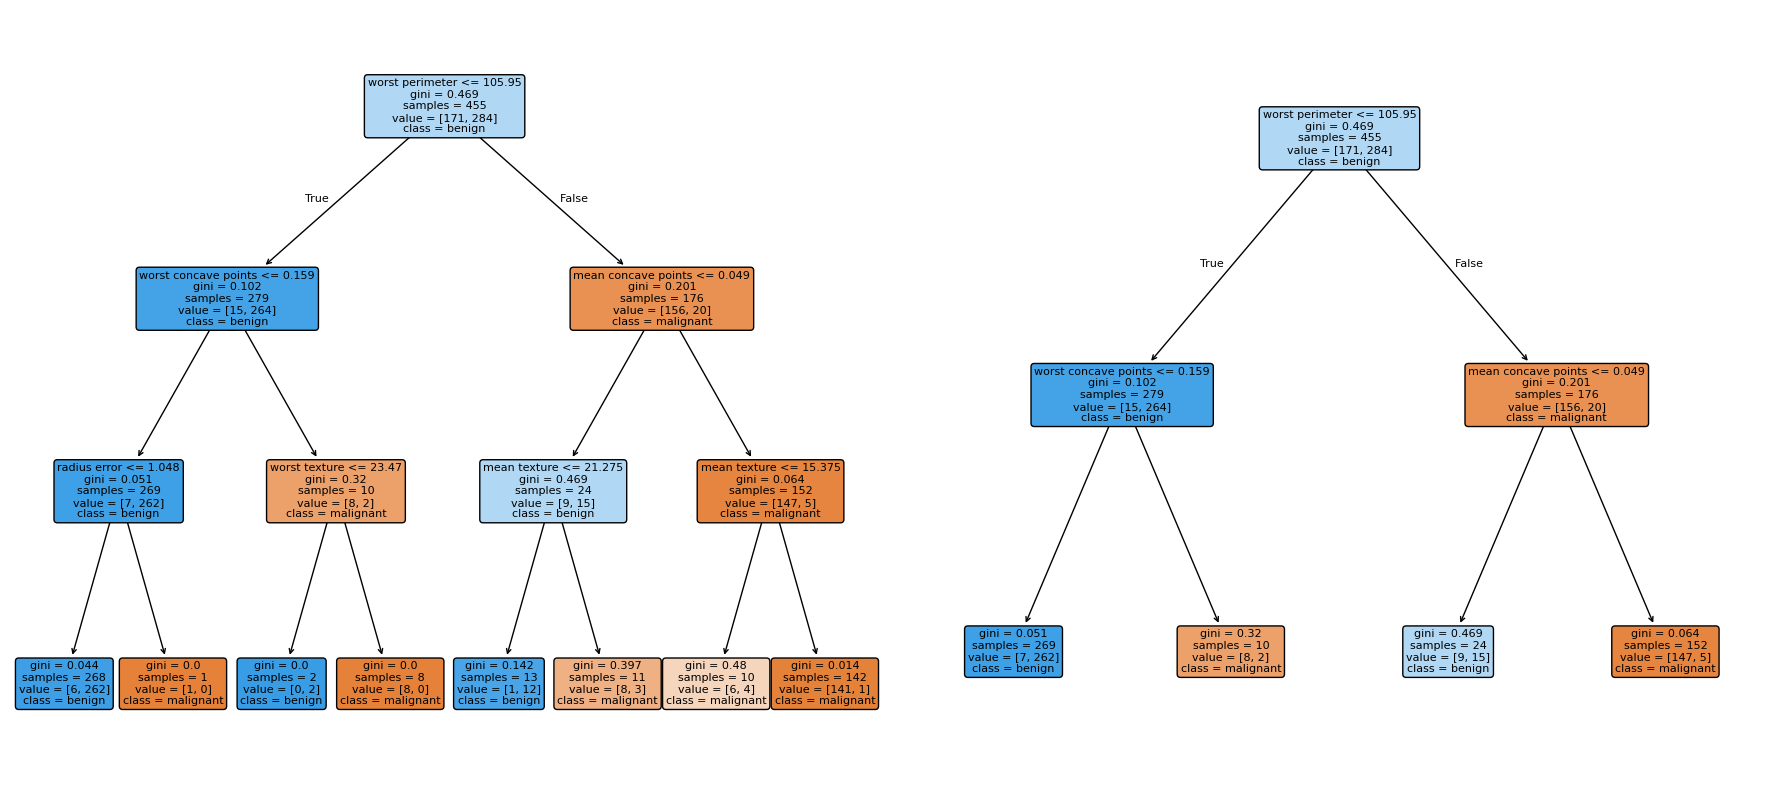

In [17]:
#Changing max depth = 3
model_depth_3 = DecisionTreeClassifier(max_depth=3, random_state=0)
model_depth_3.fit(X_train, y_train)

#Number of leaves in the tree
model_leaf_4 = DecisionTreeClassifier(max_leaf_nodes=4, random_state=0)
model_leaf_4.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(18,8))

axes[0].set_title("max_depth=3")
plot_tree(
    model_depth_3,
    feature_names = X_train.columns,
    class_names   = data.target_names,
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = axes[0]
)

axes[1].set_title("max_leaf_nodes=4")
plot_tree(
    model_leaf_4,
    feature_names = X_train.columns,
    class_names   = data.target_names,
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = axes[1]
)

plt.tight_layout()
plt.show()


1. Deep tree (left)

splits:
a. worst concave points <= 0.145
b. worst
c. area error, fractal dimension error, mean smoothness, worst concavity

leaves: small, very low-impurity groups with gini approximately 0 to 0.05

pros: very pure leaves -> high training accuracy & captures subtle interactions
cons: hard to read and likely to overfit so hard to generalize

2. Shallow tree (right)
splits:
a. worst concave points <= 0.145
b. worst area <= 957.45 for the true branch & worst area <= 710.2 for false branch

Leaves: exactly 4, each with a mix of classes (gini up to 0.496)

Pros: Extremely easy to follow by hand
Cons: underfits relative to deep tree

There are some tradeoffs, like bias and variance, increasing max_depth or max_leaf_nodes means more splits and purer leaves and better fit but lower interpretability

Decreasing them gives higher underfitting

When we change the size of the tree, we see that with no constraints that the unconstrained tree grows and grows until every leaf is pure. We get alot of levels, alot of nodes, and a near-perfect fit on training data. However, this is subjected too overfitting and as seen from above it can be hard to read by eye.

For max_depth = 3, we see the small tree is simple to follow and explains most important features. This may underfit since it didn't take into account all the subtle distinctions.

For max_leaf_nodes = 8, we have the eight "best" terminal leaves via information gain. We get some branches deeper than 3 levels if they are informative. This trades off between depth limit and pure leaves.

From changing max_depth, we force a strict limit on how many tests we see on a path. By changing max_leaf_nodes we limit how many end-points the tree can create. It depends on the problem we want to solve, how much we want to simplify for interpretability vs. how much detail / fitting power we need.

# Part c

**1. Use your training data to train a Random Forest using RandomForestClassifier.**

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

**2. Extract the feature importances from the trained model..**

In [19]:
importances = rf_model.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns)

**3. Print the feature importances from largest to smallest**

In [20]:
#we just use sort_values() method
feat_imp_sorted = feature_importance.sort_values(ascending=False)
print("Feature importances from highest to lowest:")
for feat, imp in feat_imp_sorted.items():
    print(f"{feat:25s} : {imp:.6f}")

Feature importances from highest to lowest:
worst area                : 0.121757
worst concave points      : 0.115094
worst perimeter           : 0.111194
mean concave points       : 0.099753
worst radius              : 0.098771
mean concavity            : 0.074210
mean radius               : 0.060491
mean perimeter            : 0.053150
mean area                 : 0.038448
area error                : 0.035670
worst concavity           : 0.024930
radius error              : 0.023347
mean texture              : 0.018392
worst texture             : 0.016910
worst smoothness          : 0.014905
worst symmetry            : 0.012055
worst compactness         : 0.011882
mean smoothness           : 0.008365
fractal dimension error   : 0.007918
mean compactness          : 0.006951
perimeter error           : 0.006881
worst fractal dimension   : 0.006850
compactness error         : 0.004863
concave points error      : 0.004488
concavity error           : 0.004188
mean symmetry             : 0.0

# Part d

**1. Build and train an AdaBoostClassifier on your training data using a decision tree of max depth equal to 1 as your weak learner.**

In [21]:
ada_boost_m = AdaBoostClassifier(
    estimator     = DecisionTreeClassifier(max_depth=1),
    n_estimators  = 50,
    learning_rate = 1.0,
    random_state  = 0
)

ada_boost_m.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=0)

**2. Evaluate your decision tree, random forest, and AdaBoost models by applying accuracy_score to the test data. Which model performs the best? Experiment by changing the hyperparameters of these models.**

In [22]:
#just to recall the prior stuff for convenience
model        # my DecisionTreeClassifier
rf_model     # my RandomForestClassifier
ada_boost_m  # my AdaBoostClassifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=0)

Here are the predictions by feeding in the test data

In [23]:
prediction_dt = model.predict(X_test)
prediction_dt_rf = rf_model.predict(X_test)
prediction_dt_ab = ada_boost_m.predict(X_test)

In [26]:
accuracy_dt = accuracy_score(y_test, prediction_dt)
accuracy_rf = accuracy_score(y_test, prediction_dt_rf)
accuracy_ab = accuracy_score(y_test, prediction_dt_ab)

print(f"Decision Tree accuracy   = {accuracy_dt:.4f}")
print(f"Random Forest accuracy   = {accuracy_rf:.4f}")
print(f"AdaBoost accuracy        = {accuracy_ab:.4f}")

Decision Tree accuracy   = 0.9211
Random Forest accuracy   = 0.9737
AdaBoost accuracy        = 0.9649


We see random forest wins followed by adaboost then a decision tree

Let's experiment with hyperparameters

In [36]:
# Slightly deeper single tree
dt2 = DecisionTreeClassifier(max_depth=3, random_state=2)

# More & shallower trees
rf2 = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=2)

# More AdaBoost rounds, slower learning
ab2 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=2
)

tweaks = {
    "DT max_depth=3"           : dt2,
    "RF 200 trees, depth=5"    : rf2,
    "AB 100 estimators, learning rate=0.5"      : ab2,
}

print("\nAfter hyper‐parameter changes:")
for name, mdl in tweaks.items():
    mdl.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, mdl.predict(X_test))
    print(f" • {name:25s} gives {accuracy:.10f}")



After hyper‐parameter changes:
 • DT max_depth=3            gives 0.9298245614
 • RF 200 trees, depth=5     gives 0.9649122807
 • AB 100 estimators, learning rate=0.5 gives 0.9649122807


In [34]:
models = {
    "DT (baseline)" : DecisionTreeClassifier(random_state=2),
    "RF (baseline)" : RandomForestClassifier(random_state=2),
    "AB (baseline)" : AdaBoostClassifier(random_state=2),
    "DT (tuned)"    : DecisionTreeClassifier(max_depth=3, random_state=2),
    "RF (tuned)"    : RandomForestClassifier(n_estimators=200, max_depth=5, random_state=2),
    "AB (tuned)"    : AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=2),
}

# score
results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[name] = accuracy_score(y_test, preds)


for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name} accuracy = {acc:.10f}")

RF (baseline) accuracy = 0.9649122807
AB (baseline) accuracy = 0.9649122807
RF (tuned) accuracy = 0.9649122807
AB (tuned) accuracy = 0.9649122807
DT (tuned) accuracy = 0.9298245614
DT (baseline) accuracy = 0.9035087719


It's interesting to see that both Random Forest and AdaBoost, whether I stick with the defaults or tweak their settings, land at about 96.5% accuracy, so the extra tuning didn't really move the needle. By contrast, a single decision tree starts around 90.4% and climbs to roughly 93.0% once I cap its depth at three. That little depth limit gives the single tree a nice boost, but it's clear that the ensemble methods are doing the heavy lifting on this dataset and aren't too fussy about the exact parameters I choose. Let's try to plot a bar plot

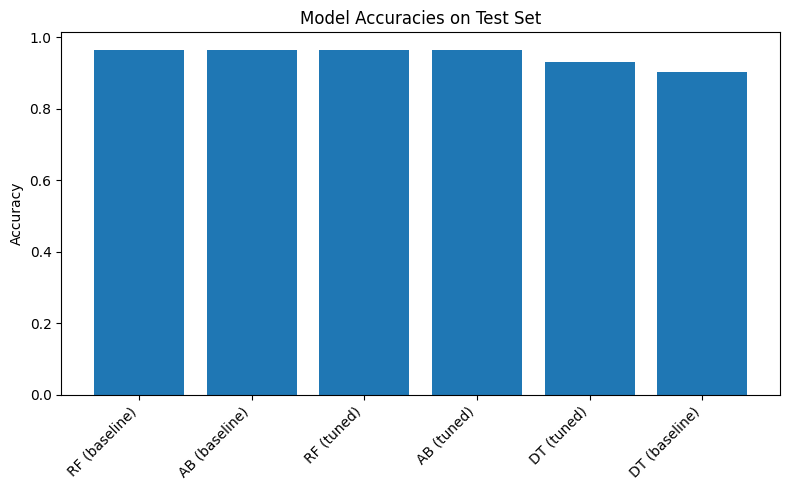

In [37]:
results = {
    "RF (baseline)": 0.9649122807,
    "AB (baseline)": 0.9649122807,
    "RF (tuned)"   : 0.9649122807,
    "AB (tuned)"   : 0.9649122807,
    "DT (tuned)"   : 0.9298245614,
    "DT (baseline)": 0.9035087719,
}

# Plot bar chart
names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8, 5))
plt.bar(names, accuracies)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Accuracies on Test Set")
plt.tight_layout()
plt.show()

You can see that both Random Forest and AdaBoost sit at about 96.5% accuracy no matter how you tweak them, while the basic decision tree only manages around 90% and even with tuning tops out near 93%.

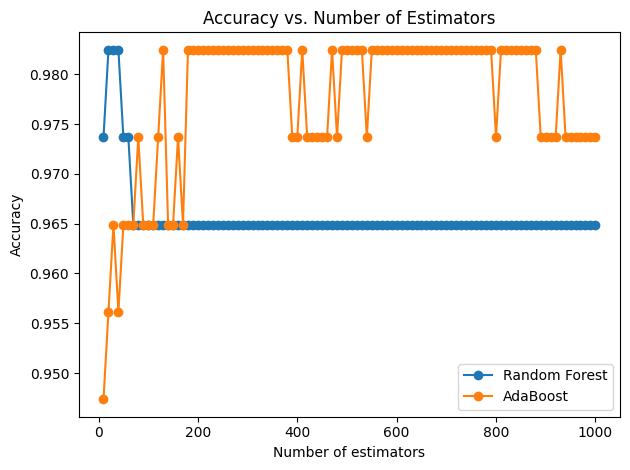

In [45]:
estimators = list(range(10, 1001, 10))
rf_scores = []
ab_scores = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=2)
    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

    ab = AdaBoostClassifier(n_estimators=n, random_state=2)
    ab.fit(X_train, y_train)
    ab_scores.append(accuracy_score(y_test, ab.predict(X_test)))

plt.figure()
plt.plot(estimators, rf_scores, marker='o', label='Random Forest')
plt.plot(estimators, ab_scores, marker='o', label='AdaBoost')
plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Estimators")
plt.legend()
plt.tight_layout()
plt.show()

The plot shows that Random Forest quickly levels off around 96.5% accuracy no matter how many trees I use, while AdaBoost steadily climbs from about 94.8% with 10 estimators up to roughly 98% by around 200-300 estimators, then gently fluctuates thereafter.